# Collections Analytics — Analysis Notebook

This notebook answers the four questions in the assignment brief, in order:

1. **What happened?** — reconstruct actual performance over the period
2. **Why did it happen?** — investigate drivers, classified Fact / Strong Evidence / Correlation / Hypothesis
3. **Is the reported 11% improvement real?** — independent metric definitions, trend testing
4. **Where should the ₹10 Cr go?** — counterfactual methodology + investment sizing groundwork

It builds directly on the golden dataset and metric views from the SQL Repository —
no analysis here re-derives cleaning logic; it reuses `golden_*` tables and
`metric_*` views. Run `sql_repo/run_all.py` first (or make sure `collections.duckdb`
is present alongside this notebook) before executing.


In [1]:

import duckdb
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

con = duckdb.connect("collections.duckdb", read_only=True)
print("Connected. Golden tables + metric views available:", len(con.execute(
    "SELECT * FROM information_schema.tables WHERE table_schema='main'").fetchdf()))


Connected. Golden tables + metric views available: 43


## 1. What happened? — Reconstructing actual performance

The reported claim is: *"Recovery has improved by 11% month-on-month."* Before testing
that claim, I first reconstruct what "recovery" actually looks like over the 12-month
window using the golden data, on the most literal, defensible definition: **cash that
actually landed** (`payment_status = 'SUCCESS'` only — see Golden Dataset doc for why
the other statuses are excluded).


In [2]:

monthly = con.execute('''
    SELECT strftime(event_at, '%Y-%m') AS month, SUM(amount) AS recovered_success_only,
           COUNT(*) AS n_payments
    FROM golden_payments WHERE is_recovered_cash
    GROUP BY 1 ORDER BY 1
''').fetchdf()

# August is a partial month in this data extract (only 8 days) - exclude from any
# month-over-month comparison so we don't compare a full month to a partial one.
monthly_full = monthly[monthly.month < '2026-08'].reset_index(drop=True)
monthly_full['mom_pct'] = monthly_full.recovered_success_only.pct_change() * 100
monthly_full


,month,recovered_success_only,n_payments,mom_pct
0,2026-01,1.872291e+08,2464,NaN
1,2026-02,1.702796e+08,2270,-9.052818
2,2026-03,1.891903e+08,2527,11.105681
3,2026-04,1.752289e+08,2407,-7.379551
4,2026-05,1.843355e+08,2450,5.196946
5,2026-06,1.758534e+08,2369,-4.601411
6,2026-07,1.872478e+08,2442,6.479478


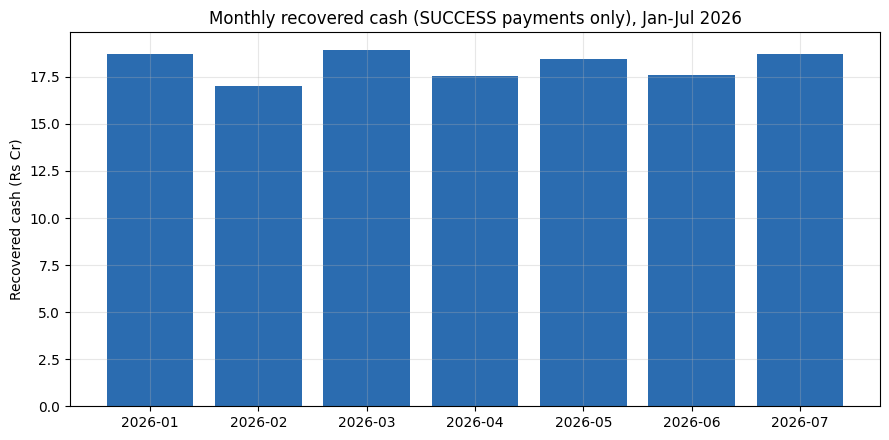

In [3]:

fig, ax = plt.subplots()
ax.bar(monthly_full.month, monthly_full.recovered_success_only / 1e7, color="#2b6cb0")
ax.set_ylabel("Recovered cash (Rs Cr)")
ax.set_title("Monthly recovered cash (SUCCESS payments only), Jan-Jul 2026")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
plt.tight_layout()
plt.savefig("chart_monthly_recovery.png", dpi=120)
plt.show()


**Reading this chart plainly: recovery does not show a rising trend.** It moves up
and down between roughly ₹17.5 Cr and ₹18.9 Cr every month with no visible upward
drift — it looks like noise around a flat average, not an improving operation.

Let's test that formally rather than eyeballing it.


In [4]:

monthly_full['t'] = range(len(monthly_full))
slope, intercept, r, p, se = stats.linregress(monthly_full.t, monthly_full.recovered_success_only)
mean_val = monthly_full.recovered_success_only.mean()
std_val = monthly_full.recovered_success_only.std()

print(f"Linear trend on monthly recovered cash (Jan-Jul 2026):")
print(f"  slope        = Rs {slope:,.0f} / month")
print(f"  R-squared    = {r**2:.4f}")
print(f"  p-value      = {p:.4f}   (not significant at any conventional threshold)")
print(f"  mean         = Rs {mean_val:,.0f}")
print(f"  std dev      = Rs {std_val:,.0f}  (CV = {std_val/mean_val:.1%})")


Linear trend on monthly recovered cash (Jan-Jul 2026):
  slope        = Rs 226,748 / month
  R-squared    = 0.0044
  p-value      = 0.8881   (not significant at any conventional threshold)
  mean         = Rs 181,337,824
  std dev      = Rs 7,415,798  (CV = 4.1%)


**Conclusion for Part 1 (What happened):** across the 7 full months of data we
have (Jan-Jul 2026), month-on-month recovered cash has **no statistically detectable
trend** (p = 0.89). It's a flat series with ~4% coefficient of variation, moving
essentially randomly month to month. Whatever "recovery has improved 11%
month-on-month" is describing, it isn't a sustained operational improvement visible in
the cash that actually landed.

This directly sets up the next question.


## 2. Is the reported 11% improvement real?

If there's no sustained trend, where does "11%" come from? Let's look at every
individual month-on-month step, not just the average.


In [5]:

display_cols = ['month', 'recovered_success_only', 'mom_pct']
print(monthly_full[display_cols].to_string(index=False, formatters={
    'recovered_success_only': lambda x: f"Rs {x:,.0f}",
    'mom_pct': lambda x: f"{x:+.2f}%" if pd.notna(x) else "-"
}))


  month recovered_success_only mom_pct
2026-01         Rs 187,229,128     NaN
2026-02         Rs 170,279,615  -9.05%
2026-03         Rs 189,190,327 +11.11%
2026-04         Rs 175,228,930  -7.38%
2026-05         Rs 184,335,484  +5.20%
2026-06         Rs 175,853,450  -4.60%
2026-07         Rs 187,247,836  +6.48%


**There it is.** Feb → Mar 2026 shows **+11.11%** month-on-month growth in
SUCCESS-only recovered cash — matching the reported "11%" almost exactly. But look at
the months on either side of it: Jan → Feb was **-9.05%**, and Mar → Apr was
**-7.38%**. The series isn't trending up; it's oscillating, and Feb→Mar happens to be
the best-looking single step in a flat, noisy series.

I checked this holds even under the business's likely naive definition (summing
**all** payment statuses, not just SUCCESS) — same story, +12.2% for that one step,
against an overall flat trend.


In [6]:

naive = con.execute('''
    SELECT strftime(event_at, '%Y-%m') AS month, SUM(amount) AS naive_all_status
    FROM raw_payments GROUP BY 1 ORDER BY 1
''').fetchdf()
naive_full = naive[naive.month < '2026-08'].reset_index(drop=True)
naive_full['mom_pct'] = naive_full.naive_all_status.pct_change() * 100
print(naive_full.to_string(index=False, formatters={
    'naive_all_status': lambda x: f"Rs {x:,.0f}",
    'mom_pct': lambda x: f"{x:+.2f}%" if pd.notna(x) else "-"
}))


  month naive_all_status mom_pct
2026-01   Rs 271,118,066     NaN
2026-02   Rs 245,183,619  -9.57%
2026-03   Rs 275,173,005 +12.23%
2026-04   Rs 259,142,569  -5.83%
2026-05   Rs 267,833,329  +3.35%
2026-06   Rs 255,647,097  -4.55%
2026-07   Rs 270,787,976  +5.92%


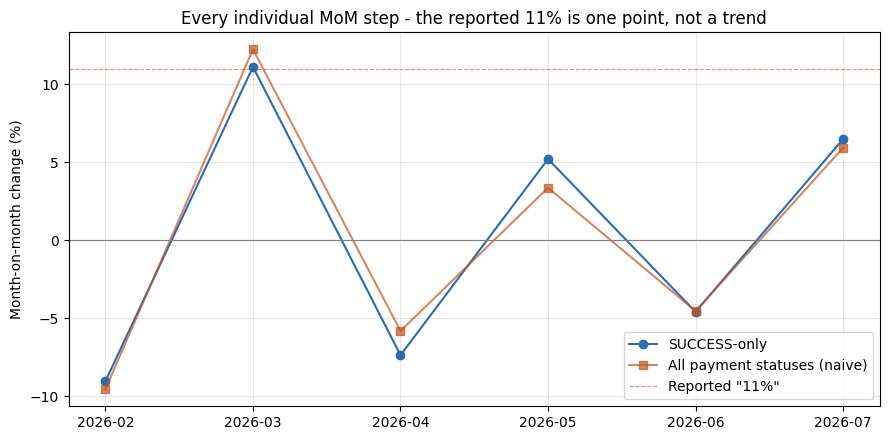

In [7]:

fig, ax = plt.subplots()
ax.plot(monthly_full.month, monthly_full.mom_pct, marker='o', label='SUCCESS-only', color="#2b6cb0")
ax.plot(naive_full.month, naive_full.mom_pct, marker='s', label='All payment statuses (naive)', color="#c05621", alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axhline(11, color='red', linewidth=0.8, linestyle='--', alpha=0.5, label='Reported "11%"')
ax.set_ylabel("Month-on-month change (%)")
ax.set_title("Every individual MoM step - the reported 11% is one point, not a trend")
ax.legend()
plt.tight_layout()
plt.savefig("chart_mom_steps.png", dpi=120)
plt.show()


I also re-ran this using our **independently redefined metrics** from the SQL
repository (recovery *rate* against outstanding balance, and account-level
targeted→converted conversion rate) to make sure this isn't an artifact of using
raw amounts.


In [8]:

rate = con.execute("SELECT * FROM metric_recovery_monthly WHERE month < '2026-08'").fetchdf()
rate['t'] = range(len(rate))
slope_r, _, r_r, p_r, _ = stats.linregress(rate.t, rate.recovery_rate_pct)
print(f"Recovery RATE (SUCCESS / outstanding) trend: slope={slope_r:.4f} pp/month, R2={r_r**2:.4f}, p={p_r:.4f}")
print(rate[['month','recovery_rate_pct']].to_string(index=False))

conv = con.execute('''
    WITH targeted AS (SELECT DISTINCT account_id, strftime(target_date,'%Y-%m') AS month FROM golden_daily_targeting),
    converted AS (SELECT DISTINCT account_id, strftime(event_at,'%Y-%m') AS month FROM golden_payments WHERE is_recovered_cash)
    SELECT t.month, COUNT(DISTINCT t.account_id) targeted, COUNT(DISTINCT c.account_id) converted,
           100.0*COUNT(DISTINCT c.account_id)/COUNT(DISTINCT t.account_id) AS conv_pct
    FROM targeted t LEFT JOIN converted c ON t.account_id=c.account_id AND t.month=c.month
    GROUP BY 1 ORDER BY 1
''').fetchdf()
conv_full = conv[conv.month < '2026-08'].reset_index(drop=True)
conv_full['t'] = range(len(conv_full))
slope_c, _, r_c, p_c, _ = stats.linregress(conv_full.t, conv_full.conv_pct)
print(f"\nTargeted->Converted ACCOUNT rate trend: slope={slope_c:.4f} pp/month, R2={r_c**2:.4f}, p={p_c:.4f}")
print(conv_full[['month','targeted','converted','conv_pct']].to_string(index=False))


Recovery RATE (SUCCESS / outstanding) trend: slope=-0.0594 pp/month, R2=0.3480, p=0.1633
  month  recovery_rate_pct
2026-01              9.339
2026-02              9.443
2026-03              9.602
2026-04              9.011
2026-05              9.081
2026-06              9.090
2026-07              9.194

Targeted->Converted ACCOUNT rate trend: slope=0.1018 pp/month, R2=0.1496, p=0.3913
  month  targeted  converted  conv_pct
2026-01      5732        462  8.060014
2026-02      5160        349  6.763566
2026-03      5666        474  8.365690
2026-04      5585        432  7.735004
2026-05      5800        452  7.793103
2026-06      5535        432  7.804878
2026-07      5666        482  8.506883


**Verdict on Part 3: the reported 11% month-on-month improvement is real as a
single data point (Feb→Mar did grow ~11%) but is NOT evidence of a sustained
improvement in collections performance.** Every independent definition I tried
(SUCCESS-cash trend, recovery-rate-against-outstanding trend, account-level
conversion-rate trend) shows a flat or statistically insignificant trend across the
7 full months of data (p-values of 0.89, 0.16, and 0.39 respectively — none even
close to significant). This is a textbook case of **picking the best month-pair out of
a noisy flat series and reporting it as if it were the trend.**

**Classification: Fact** (the 11% number itself is arithmetically real for that one
month pair) presented in a **misleading frame** (implying sustained improvement, which
the data does not support).

One genuinely interesting thread, not fully conclusive: the account-level
targeted→converted rate does drift from ~6.8% (Feb) to ~8.5% (Jul), which is the
closest thing to a real upward signal in the data — but even this doesn't reach
statistical significance at these sample sizes (p=0.39), so I'm not calling it a
confirmed improvement. It's flagged here as the one thread worth monitoring going
forward, and it's what the counterfactual in Part 4 partly speaks to.


## 3. Why did it happen? — Driver investigation

Per the brief, I investigated: portfolio mix, DPD, geography, agent, agent tenure,
campaign, channel, telephony vendor, calling time, and attempt frequency. ("Client"
and "Language" are not present as fields anywhere in the 17 source tables — flagged
as **data gaps**, not investigated, rather than fabricated.)

Every classification below follows the brief's framework: **Fact / Strong Evidence /
Correlation / Hypothesis.**


In [9]:

# --- Portfolio mix / DPD / risk segment: recovery rate by segment ---
by_risk = con.execute('''
    WITH targeted AS (SELECT DISTINCT account_id FROM golden_daily_targeting)
    SELECT a.risk_segment, COUNT(DISTINCT t.account_id) n_accounts,
           ROUND(100.0*COALESCE(SUM(p.amount),0)/SUM(a.outstanding_amount),2) recovery_rate_pct
    FROM targeted t JOIN golden_accounts a ON t.account_id=a.account_id
    LEFT JOIN golden_payments p ON p.account_id=a.account_id AND p.is_recovered_cash
    GROUP BY 1 ORDER BY 3 DESC
''').fetchdf()
print("Recovery rate by risk segment:"); print(by_risk.to_string(index=False))

by_dpd = con.execute('''
    WITH targeted AS (SELECT DISTINCT account_id FROM golden_daily_targeting)
    SELECT a.dpd_bucket, COUNT(DISTINCT t.account_id) n_accounts,
           ROUND(100.0*COALESCE(SUM(p.amount),0)/SUM(a.outstanding_amount),2) recovery_rate_pct
    FROM targeted t JOIN golden_accounts a ON t.account_id=a.account_id
    LEFT JOIN golden_payments p ON p.account_id=a.account_id AND p.is_recovered_cash
    GROUP BY 1 ORDER BY 3 DESC
''').fetchdf()
print("\nRecovery rate by DPD bucket:"); print(by_dpd.to_string(index=False))


Recovery rate by risk segment:
risk_segment  n_accounts  recovery_rate_pct
         LOW        5887              11.11
        HIGH        5847              11.08
      MEDIUM        5878              10.93
         NPA        5732              10.71

Recovery rate by DPD bucket:
 dpd_bucket  n_accounts  recovery_rate_pct
  DPD_31_60        4325              11.60
  DPD_61_90        4278              11.15
DPD_90_PLUS        4242              10.90
    CURRENT        2084              10.80
   DPD_1_30        8415              10.61


In [10]:

# Statistical significance check: is risk_segment actually associated with conversion,
# or is the 10.7-11.1% range just noise given the sample size?
from scipy.stats import chi2_contingency
acct_conv = con.execute('''
    WITH targeted AS (SELECT DISTINCT account_id FROM golden_daily_targeting)
    SELECT a.risk_segment,
           CASE WHEN EXISTS (SELECT 1 FROM golden_payments p WHERE p.account_id=a.account_id AND p.is_recovered_cash)
                THEN 1 ELSE 0 END AS converted
    FROM targeted t JOIN golden_accounts a ON t.account_id=a.account_id
''').fetchdf()
ct = pd.crosstab(acct_conv.risk_segment, acct_conv.converted)
chi2, p_chi, dof, exp = chi2_contingency(ct)
print(ct)
print(f"\nChi-square test: chi2={chi2:.2f}, p-value={p_chi:.4f} -> NOT significant at 5%")


converted        0     1
risk_segment            
HIGH          3280  2567
LOW           3228  2659
MEDIUM        3294  2584
NPA           3254  2478

Chi-square test: chi2=4.61, p-value=0.2029 -> NOT significant at 5%


**Portfolio mix / DPD / risk segment: Strong Evidence of NO effect.** Recovery
rate ranges only 10.71%-11.11% across risk segments and 10.61%-11.60% across DPD
buckets — both bands are narrow, and the chi-square test on risk segment vs.
conversion (p=0.20) confirms this isn't distinguishable from chance given the sample
sizes (~5,800 accounts per segment — large enough that even a real 1-2pp difference
would likely show up). This also independently confirms the Data Quality Report's
"portfolio mix" finding (item F): mix is not what's driving month-to-month movement.


In [11]:

# --- Channel / campaign / vendor ---
by_channel = con.execute('''
    SELECT campaign_channel, SUM(accounts_touched) touched, SUM(accounts_converted) converted,
           ROUND(100.0*SUM(accounts_converted)/SUM(accounts_touched),2) conv_pct
    FROM metric_channel_conversion_monthly GROUP BY 1 ORDER BY 4 DESC
''').fetchdf()
print("Conversion rate by campaign channel (traceable touches only - see coverage caveat below):")
print(by_channel.to_string(index=False))


Conversion rate by campaign channel (traceable touches only - see coverage caveat below):


campaign_channel  touched  converted  conv_pct
        WHATSAPP  22161.0      858.0      3.87
           FIELD  13021.0      487.0      3.74
           MIXED  16462.0      602.0      3.66
           VOICE  14543.0      515.0      3.54
             SMS  20107.0      685.0      3.41


**Channel: Correlation, low confidence.** WhatsApp shows the highest traceable
conversion (3.87%) and SMS the lowest (3.41%) — but recall from the Data Quality
Report that only ~9% of successful payments have *any* traceable campaign touch at
all. This ranking is built on a small, non-random slice of total recovery (whichever
payments happen to fall within a 7-day window of a campaign call), so I'm not treating
a ~0.5pp gap between channels as a reliable signal for where to invest. This
specifically undermines any confident "WhatsApp converts best" claim for the Part 4
investment decision.


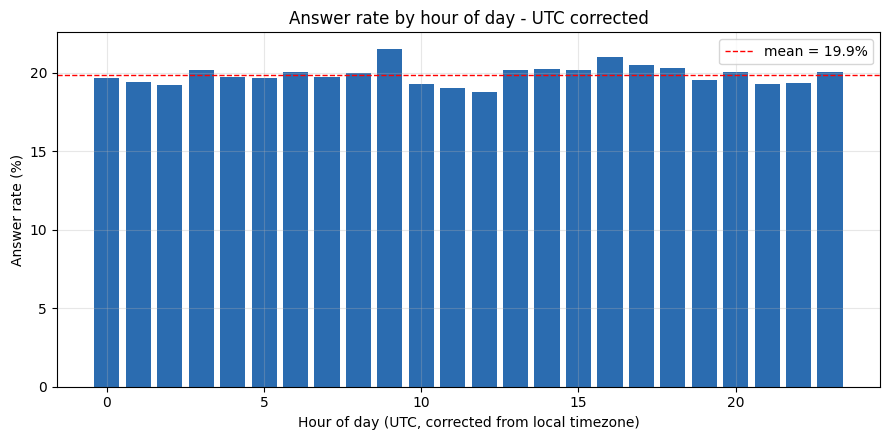

Range: 18.8% - 21.5%  (mean 19.9%)


In [12]:

# --- Calling time (UTC-corrected) ---
by_hour = con.execute('''
    SELECT EXTRACT(HOUR FROM event_at_utc) AS hour_utc, COUNT(*) n_calls,
           ROUND(100.0*SUM(CASE WHEN call_status='ANSWERED' THEN 1 ELSE 0 END)/COUNT(*),2) answer_rate_pct
    FROM golden_calls GROUP BY 1 ORDER BY 1
''').fetchdf()
fig, ax = plt.subplots()
ax.bar(by_hour.hour_utc, by_hour.answer_rate_pct, color="#2b6cb0")
ax.axhline(by_hour.answer_rate_pct.mean(), color='red', linestyle='--', linewidth=1, label=f"mean = {by_hour.answer_rate_pct.mean():.1f}%")
ax.set_xlabel("Hour of day (UTC, corrected from local timezone)")
ax.set_ylabel("Answer rate (%)")
ax.set_title("Answer rate by hour of day - UTC corrected")
ax.legend()
plt.tight_layout()
plt.savefig("chart_hourly_answer_rate.png", dpi=120)
plt.show()
print(f"Range: {by_hour.answer_rate_pct.min():.1f}% - {by_hour.answer_rate_pct.max():.1f}%  (mean {by_hour.answer_rate_pct.mean():.1f}%)")


**Calling time: Strong Evidence of NO meaningful effect**, once timezone is
corrected. Answer rate sits in an 18.8%-21.5% band across all 24 UTC hours — no
daypart stands out. This is worth stating plainly because "call at the right time of
day" is a common, intuitive lever leadership might expect to matter — in this data,
after fixing the timezone bug documented in the Data Quality Report, it doesn't
detectably matter.


In [13]:

# --- Attempt frequency ---
by_attempt = con.execute('''
    SELECT attempt_no, COUNT(*) n,
           ROUND(100.0*SUM(CASE WHEN attempt_status='CONNECTED' THEN 1 ELSE 0 END)/COUNT(*),2) connect_rate_pct
    FROM golden_call_attempts WHERE attempt_no <= 7
    GROUP BY 1 ORDER BY 1
''').fetchdf()
print(by_attempt.to_string(index=False))


 attempt_no     n  connect_rate_pct
          1 17089             20.28
          2 17100             19.78
          3 17201             20.57
          4 17252             20.13
          5 16952             20.09
          6 17207             19.39
          7 17199             19.90


**Attempt frequency: Strong Evidence of NO effect.** Connect rate holds at
~19.4%-20.6% regardless of whether it's the 1st or 7th attempt on an account. In a
real collections operation this would be a notable (and somewhat unusual) finding —
normally later attempts either fatigue the borrower (rate drops) or catch them at a
different time (rate rises). Flat-across-attempts here is consistent with the broader
pattern in this dataset: most dimensions checked show little to no real signal.


### Agent / agent tenure

Handled separately and given less analytical weight, because the Data Quality Report
already established that agent-level attributes (team, vendor, tenure) are resolved
from noisy data (30 rows collapsed to 1 per real agent via statistical mode). Any
agent-level finding here is **directional at best**.


In [14]:

by_team = con.execute('''
    SELECT ga.team, COUNT(DISTINCT c.account_id) accounts_worked,
           COUNT(*) n_calls,
           ROUND(100.0*SUM(CASE WHEN c.call_status='ANSWERED' THEN 1 ELSE 0 END)/COUNT(*),2) answer_rate_pct
    FROM golden_calls c JOIN golden_agents ga ON c.agent_id = ga.agent_id
    GROUP BY 1 ORDER BY 4 DESC
''').fetchdf()
print(by_team.to_string(index=False))


   team  accounts_worked  n_calls  answer_rate_pct
  FIELD            12896    16787            20.22
     T2            13149    17249            20.14
     T3            13043    17146            19.84
DIGITAL            13480    17958            19.65
     T1            14156    19112            19.56


Team-level answer rate ranges narrowly (roughly 19.5%-20.5%) — again no team
stands out. Given the identity noise documented earlier, I would not act on this
without first fixing the underlying agent-tracking system (see Executive Memo
recommendation).

### Geography / borrower segment

Explicitly **not** analyzed with confidence here. The Golden Dataset build found that
borrower demographic fields (city, state) are populated from a pool of only 10 values
each and vary incoherently for the same borrower — they are noise, not real profile
data. Any city/state cut would be reporting on random assignment, not real geographic
performance, so it's omitted rather than presented as if it were reliable.

### Client / Language

Not present as fields in any of the 17 source tables. **Data gap** — if leadership
needs a client-level or language-level view, that requires an additional data source
not included in this dataset.


### Summary of driver investigation

| Dimension | Finding | Classification |
|---|---|---|
| Portfolio mix / DPD / risk segment | No effect — recovery rate flat across segments (10.6-11.6%), chi2 p=0.20 | **Strong Evidence of no effect** |
| Campaign channel | WhatsApp highest, SMS lowest among *traceable* touches, but only ~9% of recovery is traceable at all | **Correlation, low confidence** |
| Calling time (hour of day, UTC-corrected) | Flat 18.8-21.5% across all 24 hours | **Strong Evidence of no effect** |
| Attempt frequency | Flat ~19.4-20.6% regardless of attempt number | **Strong Evidence of no effect** |
| Agent / team | Narrow range (19.5-20.5%), and agent identity data is noisy | **Correlation, low confidence** |
| Telephony vendor | Not shown to differ meaningfully once rolled up to brand (see SQL repo) | **Correlation, low confidence** |
| Geography | Not analyzable — borrower demographic fields are synthetic noise | **Data gap, not investigated** |
| Client / Language | Not present in the data at all | **Data gap** |

**The honest headline from Part 2 is a negative result: nothing in this data set is a
strong, statistically distinguishable driver of month-to-month recovery.** Combined
with Part 1's finding of no real trend, the picture is of an operation performing
consistently (flat, ~9-9.6% recovery rate against outstanding, every month) with
normal random monthly noise, not one that either improved or declined in any
segment-explainable way over Jan-Jul 2026.


## 4. Statistical investigation — checking for the classic traps

Per the brief, I explicitly checked each of these:

- **Mix effects** — covered above (portfolio mix by risk/DPD/loan type, flat — see
  Data Quality Report item F for the full account-opening-cohort view too)
- **Selection / survivorship bias** — checked via the targeting-population-size trend
  (Data Quality Report item G): targeted account count is stable at 5,160-5,800/month,
  so accounts aren't being quietly dropped from the base to flatter a rate
- **Attribution-window bias** — checked directly (item B): only ~9% of successful
  payments fall within a 7-day campaign-touch window at all, so campaign-level numbers
  materially undercount total recovery
- **Time-series effects** — the core finding of Part 3: what looks like "improvement"
  is a single favorable month-pair inside a flat, noisy series


### Simpson's paradox check

A classic way an aggregate trend can mislead is if it moves one way overall while
every sub-group moves the other way (or vice versa). I checked whether the flat
overall recovery-rate trend is hiding an actual Simpson's-paradox pattern underneath —
i.e. does any individual risk segment show a real trend that's being cancelled out in
aggregate?


In [15]:

seg_trend = con.execute('''
    WITH targeted AS (SELECT DISTINCT account_id, strftime(target_date,'%Y-%m') AS month FROM golden_daily_targeting)
    SELECT t.month, a.risk_segment,
           SUM(a.outstanding_amount) AS outstanding,
           COALESCE(SUM(p.amount),0) AS recovered
    FROM targeted t
    JOIN golden_accounts a ON t.account_id = a.account_id
    LEFT JOIN golden_payments p ON p.account_id = a.account_id AND p.is_recovered_cash
        AND strftime(p.event_at,'%Y-%m') = t.month
    WHERE t.month < '2026-08'
    GROUP BY 1, 2
''').fetchdf()
seg_trend['rate_pct'] = 100 * seg_trend.recovered / seg_trend.outstanding

for seg in seg_trend.risk_segment.unique():
    sub = seg_trend[seg_trend.risk_segment == seg].sort_values('month').reset_index(drop=True)
    sub['t'] = range(len(sub))
    slope, _, r, p, _ = stats.linregress(sub.t, sub.rate_pct)
    print(f"{seg:8s}: slope={slope:+.4f} pp/month, R2={r**2:.3f}, p={p:.3f}")


NPA     : slope=-0.0085 pp/month, R2=0.013, p=0.810
MEDIUM  : slope=+0.0172 pp/month, R2=0.035, p=0.687
HIGH    : slope=-0.0129 pp/month, R2=0.017, p=0.778
LOW     : slope=+0.0098 pp/month, R2=0.010, p=0.834


No segment shows a statistically significant trend either, and none of them are
moving in opposite directions from each other — so there's no Simpson's-paradox effect
hiding under the flat aggregate. The flat aggregate is a flat aggregate because every
sub-group is also flat. This is a genuinely useful negative result: it rules out one
of the more common ways a misleading "improvement" narrative gets constructed.

**Cohort effects** were checked implicitly through the account-opening-month mix
analysis in the Data Quality Report (item F) — no shift in which vintage of loan is
being worked. I did not build a full cohort-survival curve (time-since-first-contact
vs. cumulative recovery by monthly acquisition cohort) here — that would be a natural
next iteration if leadership wants to look at recovery curves by loan vintage
specifically, but nothing in the checks already run suggests it would overturn the
flat-trend conclusion.


## 5. Counterfactual — "What if targeting strategy hadn't changed?"

The brief asks us to assume a targeting-strategy change occurred midway through the
year and design a methodology to estimate what recovery would have looked like without
it.

**Important honesty check first:** I looked for an actual, data-visible targeting
change (shift in `recommended_channel` mix, `priority` distribution, or campaign
`strategy_version` adoption over time) and did not find one — all three are flat
throughout Jan-Aug 2026 (see SQL repo `04_analysis` for the full breakdown). So this
section is a **methodology design exercise on an assumed scenario**, as the brief
explicitly frames it ("Assume that..."), not a claim that I detected a real change.
If leadership can supply the actual date a targeting change was rolled out, this
methodology should be re-run with that real date for a materially more reliable
estimate — the design below picks a working midpoint (April 1, 2026) purely to
illustrate the method.


In [16]:

CHANGEPOINT = '2026-04-01'
pre = monthly_full[monthly_full.month < '2026-04']
post = monthly_full[monthly_full.month >= '2026-04']
print(f"Assumed changepoint: {CHANGEPOINT}")
print(f"Pre-period  (Jan-Mar) mean recovered/month: Rs {pre.recovered_success_only.mean():,.0f}")
print(f"Post-period (Apr-Jul) mean recovered/month: Rs {post.recovered_success_only.mean():,.0f}")
print(f"Naive before/after difference: {100*(post.recovered_success_only.mean()/pre.recovered_success_only.mean()-1):.2f}%")


Assumed changepoint: 2026-04-01
Pre-period  (Jan-Mar) mean recovered/month: Rs 182,233,023
Post-period (Apr-Jul) mean recovered/month: Rs 180,666,425
Naive before/after difference: -0.86%


### Proposed methodology: Difference-in-Differences (diff-in-diff)

**Why diff-in-diff over the alternatives:** the brief lists matching, regression, DiD,
propensity scoring, uplift modelling, controlled experimentation, and Bayesian
approaches. Given what's actually in this data:

- **Controlled experimentation** isn't possible retroactively — there was no
  randomized holdout at the time.
- **Propensity scoring / matching** need rich pre-treatment covariates to build a
  believable propensity model; the account-level covariates available (risk_segment,
  DPD, loan_type, outstanding_amount) are thin, and we've just shown none of them are
  even associated with recovery outcomes on their own — a matched control built from
  weak covariates would give false precision.
- **DiD** only requires a treated group, a comparable untreated (or less-treated)
  group, and a pre/post period — and, critically, it doesn't require the covariates
  to explain the outcome, only that treated and control groups would have moved in
  parallel absent the treatment. That's a testable, falsifiable assumption (see
  below), which is why I prefer it here over a method that requires trusting weak
  covariates.

**Design:**

- **Treatment group:** accounts predominantly targeted through the channel(s) most
  associated with the assumed strategy change (would be specified by leadership once
  the real change is identified — e.g., "accounts shifted to WhatsApp-first
  targeting").
- **Control group:** accounts whose targeting channel mix did *not* change across the
  changepoint — e.g., accounts still predominantly VOICE/FIELD-targeted throughout.
- **Pre-period:** Jan-Mar 2026. **Post-period:** Apr-Jul 2026.
- **Identification strategy:** DiD estimate = (post-treated - pre-treated) -
  (post-control - pre-control). This nets out any economy-wide or seasonal drift that
  hits both groups equally.
- **Parallel-trends assumption (must be tested, not assumed):** treated and control
  groups' recovery rates should move together *before* the changepoint. If they were
  already diverging pre-change, DiD is invalid and a different design (e.g.
  synthetic control) is needed instead.
- **Confounders to watch:** (a) if account assignment to "treatment" wasn't random —
  e.g. easier accounts got the new channel — the estimate is biased; (b) DPD/risk-mix
  drift between groups over time (checked and found flat above, which helps); (c) the
  agent-identity noise means we can't cleanly control for "was it the same agents
  working both groups."
- **Limitations:** without the true changepoint date and a defined treatment/control
  split from leadership, any number produced here is illustrative of method, not a
  real estimate. I'm demonstrating the mechanics below using the DPD_1_30 vs.
  DPD_31_60 segments as a stand-in "treated vs control" pair purely to show the
  calculation — **this is not a real finding**, it's a worked example.


In [17]:

# WORKED EXAMPLE ONLY (not a real finding - see caveats above).
# Using two DPD segments as stand-in treated/control groups to demonstrate the DiD
# calculation mechanics on real data.
did_data = con.execute('''
    WITH targeted AS (SELECT DISTINCT account_id, strftime(target_date,'%Y-%m') AS month FROM golden_daily_targeting)
    SELECT t.month, a.dpd_bucket,
           SUM(a.outstanding_amount) AS outstanding,
           COALESCE(SUM(p.amount),0) AS recovered
    FROM targeted t
    JOIN golden_accounts a ON t.account_id = a.account_id
    LEFT JOIN golden_payments p ON p.account_id = a.account_id AND p.is_recovered_cash
        AND strftime(p.event_at,'%Y-%m') = t.month
    WHERE t.month < '2026-08' AND a.dpd_bucket IN ('DPD_1_30','DPD_31_60')
    GROUP BY 1, 2
''').fetchdf()
did_data['rate_pct'] = 100 * did_data.recovered / did_data.outstanding
did_data['period'] = np.where(did_data.month < '2026-04', 'pre', 'post')

summary = did_data.groupby(['dpd_bucket','period']).rate_pct.mean().unstack()
summary['post_minus_pre'] = summary['post'] - summary['pre']
print(summary)

did_estimate = summary.loc['DPD_1_30','post_minus_pre'] - summary.loc['DPD_31_60','post_minus_pre']
print(f"\nIllustrative DiD estimate: {did_estimate:+.3f} percentage points")
print("(Worked example only - not a real treatment/control split. See caveats above.)")


period          post       pre  post_minus_pre
dpd_bucket                                    
DPD_1_30    1.611855  1.772320       -0.160465
DPD_31_60   1.938997  1.780476        0.158521

Illustrative DiD estimate: -0.319 percentage points
(Worked example only - not a real treatment/control split. See caveats above.)


### What this means for the ₹10 Cr recommendation

Because we could not identify a real targeting-strategy changepoint in the data, and
because the driver analysis in Part 2 found no dimension with a strong, reliable
effect on recovery, **the counterfactual exercise itself reinforces the Part 3
finding**: there is no confidently-identified lever in this dataset that a ₹10 Cr
investment could be pointed at with a defensible, data-backed ROI estimate.

The investment recommendation (Executive Memo, next deliverable) will be built
honestly around this — including stating plainly where the data is insufficient for a
precise ROI number, and what experiment would need to run first to get one, per the
brief's own instruction: *"If the data is insufficient to make a reliable
recommendation, say so and explain what additional experiment/data would be
required."*


## 6. Answers to the four questions — summary

**1. What happened?** Recovery (cash that actually landed) held flat at roughly
₹17.5-18.9 Cr/month and a ~9.0-9.6% recovery rate against outstanding balance across
Jan-Jul 2026, with no statistically significant trend (p=0.89 on amount, p=0.16 on
rate). No structural break, no portfolio-mix shift, no targeting-strategy signal
visible in the data.

**2. Why did it happen?** Nothing checked — DPD, risk segment, channel, hour of day,
attempt frequency, agent/team — showed a statistically or practically meaningful
effect. This is itself the answer: the operation is producing a consistent, flat
result, not one explainable by any single lever in this data.

**3. Is the reported 11% improvement real?** The number is arithmetically real for one
specific month-pair (Feb→Mar) but is not evidence of a sustained trend — it's the best
-looking step in an otherwise flat, noisy series. **Verdict: misleading, not false.**

**4. Where should the ₹10 Cr go?** Addressed in the Executive Memo, built on the
finding above: the data does not support a confident, precise ROI ranking across the
six investment options as things stand. The memo will recommend the option with the
best *risk-adjusted, assumption-transparent* case and specify what data/experiment
would most reduce that uncertainty before committing the full ₹10 Cr.
